```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [ ]:
! pip install infomeasure


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.3/259.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 13.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# To download the data, follow instructions at https://doi.org/10.7910/DVN/0SGZFF.
survey_and_browser_attrs_fpath = './survey-and-browser-attributes-data.txt'

In [ ]:
stable_ba_names = [
    'User agent', 'Languages', # Can be collected passively via HTTP headers
    'Timezone', 'Screen resolution',
    'Color depth', 'Platform', 'Touch points',
    'Hardware concurrency', 'Device memory',
    'WebGL Vendor', 'WebGL Unmasked Vendor',
    'WebGL Renderer', 'WebGL Unmasked Renderer',
]
# Replace nan values with the empty string
sba_df = pd.read_csv(survey_and_browser_attrs_fpath, usecols=['ResponseId']+stable_ba_names)
sba_df = sba_df.set_index('ResponseId').fillna('')
N = len(sba_df)
N

8400

In [ ]:
def get_unhashed_fingerprint(user_data):
  return ':'.join(pd.Series(user_data).values.astype(str).tolist())

def get_fingerprint(user_data):
  return hash(get_unhashed_fingerprint(user_data))

sba_df['Fingerprint'] = sba_df[stable_ba_names].apply(get_fingerprint, axis=1)

In [ ]:
from scipy.stats import entropy

# shannon entropy (standard measurement)
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  H = entropy(pk, base=2) # unit is bits
  return H

def get_normalized_shannon_entropy(values):
  """Returns value H(X)/H_N where H_N represents worst case where all values are unique."""
  H_N = get_shannon_entropy(list(range(len(values))))
  return get_shannon_entropy(values)/H_N

def get_reid_score(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  return pk.pow(2).sum()

def get_tsallis_entropy(values):
  return 1 - get_reid_score(values)

def get_frac_unique(values):
  value_counts = values.value_counts()
  return round((value_counts == 1).sum()/len(values), 4)


test_attr = 'User agent'
values = sba_df[test_attr]
print('%0.3f = Shannon entropy for %s' % (get_shannon_entropy(values), test_attr))
print('%0.3f = Normalized Shannon entropy for %s' % (get_normalized_shannon_entropy(values), test_attr))

4.613 = Shannon entropy for User agent
0.354 = Normalized Shannon entropy for User agent


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import infomeasure as im
from scipy.stats import entropy
import concurrent.futures
import warnings

im.Config.set_log_level("ERROR")

# --- User-defined Estimators ---
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts() / len(values)
  return entropy(pk, base=2)

def get_normalized_shannon_entropy(values):
  H_N = np.log2(len(values))
  if H_N == 0: return 0
  return get_shannon_entropy(values) / H_N

def get_tsallis_entropy(values):
  pk = pd.Series(values).value_counts() / len(values)
  return 1 - (pk**2).sum()

def im_entropy(data, approach, **kwargs):
    """
    Wraps im.entropy to handle specific Bayesian priors by calculating alpha.

    Supported bayes approaches:
      - bayes_jeffreys: alpha = 0.5
      - bayes_laplace: alpha = 1.0
      - bayes_schurmann_grassberger: alpha = 1/K
      - bayes_minimax: alpha = sqrt(N)/K
    """
    # If the approach does not start with "bayes_", call im.entropy directly
    if not approach.startswith("bayes_"):
      with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return im.entropy(data, approach=approach, **kwargs)

    # Calculate N (sample size) and K (number of unique values in data)
    N = len(data)
    K = len(set(data))

    # Extract the prior name
    prior_name = approach.replace("bayes_", "")

    # Determine alpha based on the prior
    if prior_name == "jeffreys":
        # Jeffreys Prior (alpha = 0.5)
        alpha = 0.5
    elif prior_name == "laplace":
        # Laplace Prior (alpha = 1.0)
        alpha = 1.0
    elif prior_name == "schurmann_grassberger":
        # Schürmann-Grassberger Prior (alpha = 1/K)
        alpha = 1.0 / K
    elif prior_name == "minimax":
        # Minimax Prior (alpha = sqrt(N)/K)
        alpha = np.sqrt(N) / K
    else:
        raise ValueError(f"Unknown Bayesian prior type: {prior_name}")

    # Call im.entropy with the 'bayes' approach and the calculated alpha
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")
      return im.entropy(data, approach="bayes", alpha=alpha, **kwargs)


# --- Configuration ---
attributes = (
    # stable_ba_names
    # +
     ['Fingerprint']
)
# "discrete" is the ML estimator, so it's the same as the "Shannon" line.
estimator_names = {
    "miller_madow": "Miller-Madow",
    "grassberger": "Grassberger",
    "shrink": "Shrinkage",
    "chao_shen": "Chao-Shen",
    "chao_wang_jost": "Chao-Wang-Jost",
    "bayes_jeffreys": "Bayesian (Jeffreys)",
    "bayes_laplace": "Bayesian (Laplace)",
    "bayes_schurmann_grassberger": "Bayesian (Schürmann-Grassberger)",
    "bayes_minimax": "Bayesian (Minimax)",
    "nsb": "NSB",
    "ansb": "ANSB",
    "zhang": "Zhang",
    "bonachela": "Bonachela",
}
estimators = [
    "miller_madow",
    "grassberger",
    "shrink",
    "chao_shen",
    "chao_wang_jost",
    # "nsb",
]
trials = 100
workers = 5
N = len(sba_df)
ns = list(range(200, N+1, 200))

# Colors
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
est_colors = {est: colors[i % len(colors)] for i, est in enumerate(estimators)}

# --- Helper Function for Parallelization ---
def run_trial(n, full_data, estimators):
  sample = list(full_data.sample(n=n, replace=False))

  # Current Estimators
  trial_res = {
    'Shannon Entropy': get_shannon_entropy(sample),
    'Normalized Shannon': get_normalized_shannon_entropy(sample),
    'Tsallis Entropy': get_tsallis_entropy(sample)
  }

  # Library Estimators
  for est in estimators:
    try:
      val = im_entropy(sample, approach=est, base=2)
    except:
      print(f'error {est}, {n}, {e}')
      val = np.nan

    trial_res[est] = val

  return trial_res

# --- Computation ---
print("Computing entropies (parallelized)... this may take a few minutes.")
attributes_entropy_data = {}

for attr in attributes:
  print(f"Processing {attr}...")
  full_data = sba_df[attr]

  # Initialize storage
  res = {est: [] for est in estimators}
  res['Shannon Entropy'] = []
  res['Normalized Shannon'] = []
  res['Tsallis Entropy'] = []
  res['n'] = ns

  for n in ns:
    trial_vals = {k: [] for k in res.keys() if k != 'n'}

    # Parallel Execution
    with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as exec:
      futures = [
          exec.submit(run_trial, n, full_data, estimators)
          for _ in range(1 if n == N else trials)]

      for future in concurrent.futures.as_completed(futures):
        try:
          r = future.result()
          for k, v in r.items():
              trial_vals[k].append(v)
        except Exception as e:
          print(f"Trial failed: {e}")

    # Averages over trials
    for k in trial_vals:
      res[k].append(np.nanmean(trial_vals[k]))

  df_res = pd.DataFrame(res).set_index('n')

  # --- Calculate Relative Errors ---
  for est in estimators + ['Shannon Entropy', 'Tsallis Entropy']:
    pop_est = df_res[est][N]
    df_res[f'{est}_error'] = (df_res[est] - pop_est).abs() / pop_est

  attributes_entropy_data[attr] = df_res


Computing entropies (parallelized)... this may take a few minutes.
Processing Fingerprint...


Generating plots...


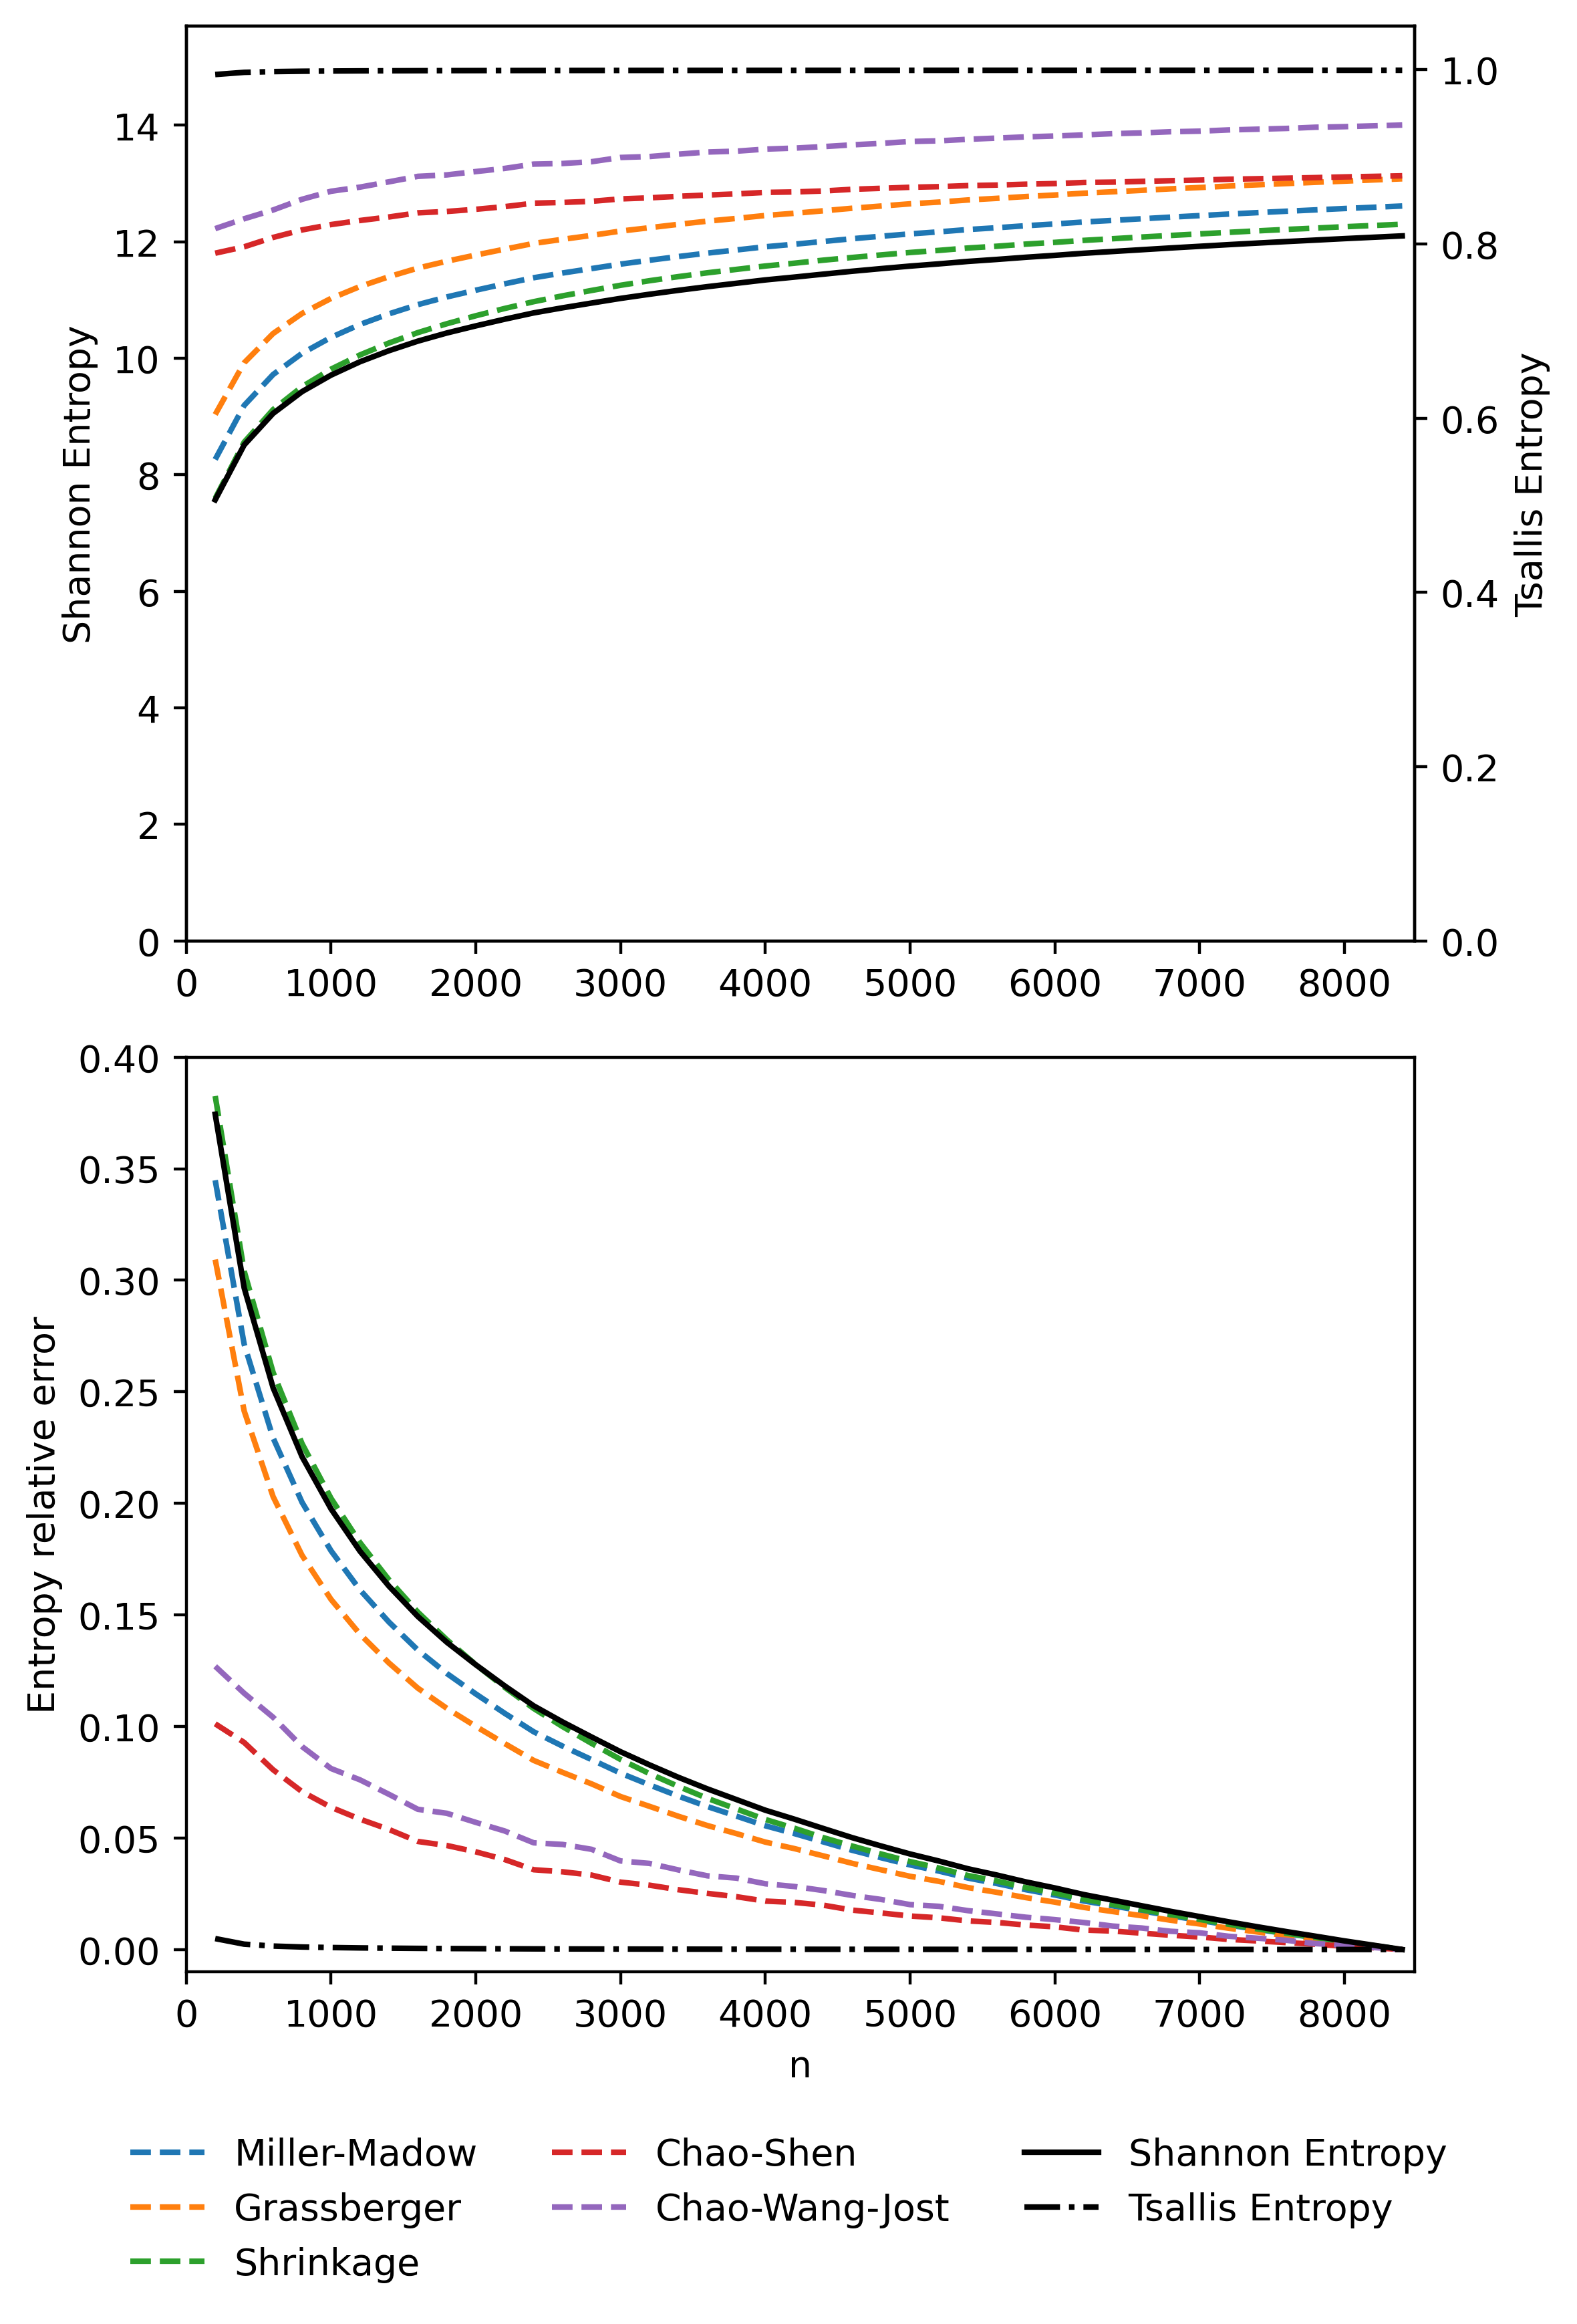

In [ ]:
# --- Plotting ---
print("Generating plots...")

fig, axes = plt.subplots(
    2 * len(attributes), 1, figsize=(6, 8), dpi=400, squeeze=False)

for i, a in enumerate(attributes):
    data = attributes_entropy_data[a]

    # 1. Combined Shannon and Tsallis Entropy Plot
    ax_shannon = axes[2*i][0]
    for est in estimators:
        ax_shannon.plot(
            data.index,
            data[est],
            linestyle='dashed',
            color=est_colors[est])
    ax_shannon.plot(data.index, data['Shannon Entropy'], color='black')
    ax_shannon.set_ylabel('Shannon Entropy')
    ax_shannon.set_ylim(0, 15.7)
    ax_shannon.set_xlim(0, N*1.01)
    ax_shannon.grid(False)

    # Create twin axis for Tsallis Entropy
    ax_tsallis = ax_shannon.twinx()
    ax_tsallis.plot(
        data.index, data['Tsallis Entropy'], color='black', linestyle='-.')
    ax_tsallis.set_ylabel('Tsallis Entropy')
    ax_tsallis.set_ylim(0, 1.05)
    ax_tsallis.grid(False)

    # 2. Relative Error Plot
    ax_err = axes[2*i + 1][0]
    for est in estimators:
        ax_err.plot(
            data.index,
            data[f'{est}_error'],
            linestyle='dashed',
            color=est_colors[est],
            label=estimator_names[est])
    ax_err.plot(
        data.index,
        data['Shannon Entropy_error'],
        color='black',
        label='Shannon Entropy')
    ax_err.plot(
        data.index,
        data['Tsallis Entropy_error'],
        color='black',
        linestyle='-.',
        label='Tsallis Entropy')
    ax_err.set_ylabel('Entropy relative error')
    ax_err.set_ylim(-0.01, 0.4)
    ax_err.set_xlim(0, N*1.01)
    ax_err.grid(False)

    # Keep only the bottom-most xlabel
    if i == len(attributes) - 1:
        ax_err.set_xlabel('n')

fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=3, frameon=False, fontsize=10
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()